In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

import thermoift.PLOT_SETTINGS as ps

In [2]:
# Load dataset (same as pre_processing.ipynb)
df = pd.read_csv("interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19171

P_bubble statistics:
count    19171.000000
mean        38.270487
std         20.467106
min          3.181219
25%         21.341211
50%         35.985782
75%         54.333096
max        108.401596
Name: P_bubble, dtype: float64


In [3]:
# Target variable
target = "P_bubble"

# Components (same as pre_processing.ipynb)
COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide"
]

z_columns = [f"z_{comp}" for comp in COMPONENTS]

# Features - same structure as preprocessor
features = [col for col in df.columns if col in ["temperature", "pressure"] + z_columns]

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# Train-test split (same random_state as preprocessor)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples: 15336
Testing samples:  3835


Feature correlations with P_bubble:
pressure              0.854181
z_hydrogen            0.648953
temperature           0.634219
z_nitrogen            0.062354
z_carbon monoxide     0.054728
z_oxygen             -0.035170
z_argon              -0.058853
z_methane            -0.094578
z_hydrogen sulfide   -0.101637
z_carbon dioxide     -0.309526
Name: P_bubble, dtype: float64


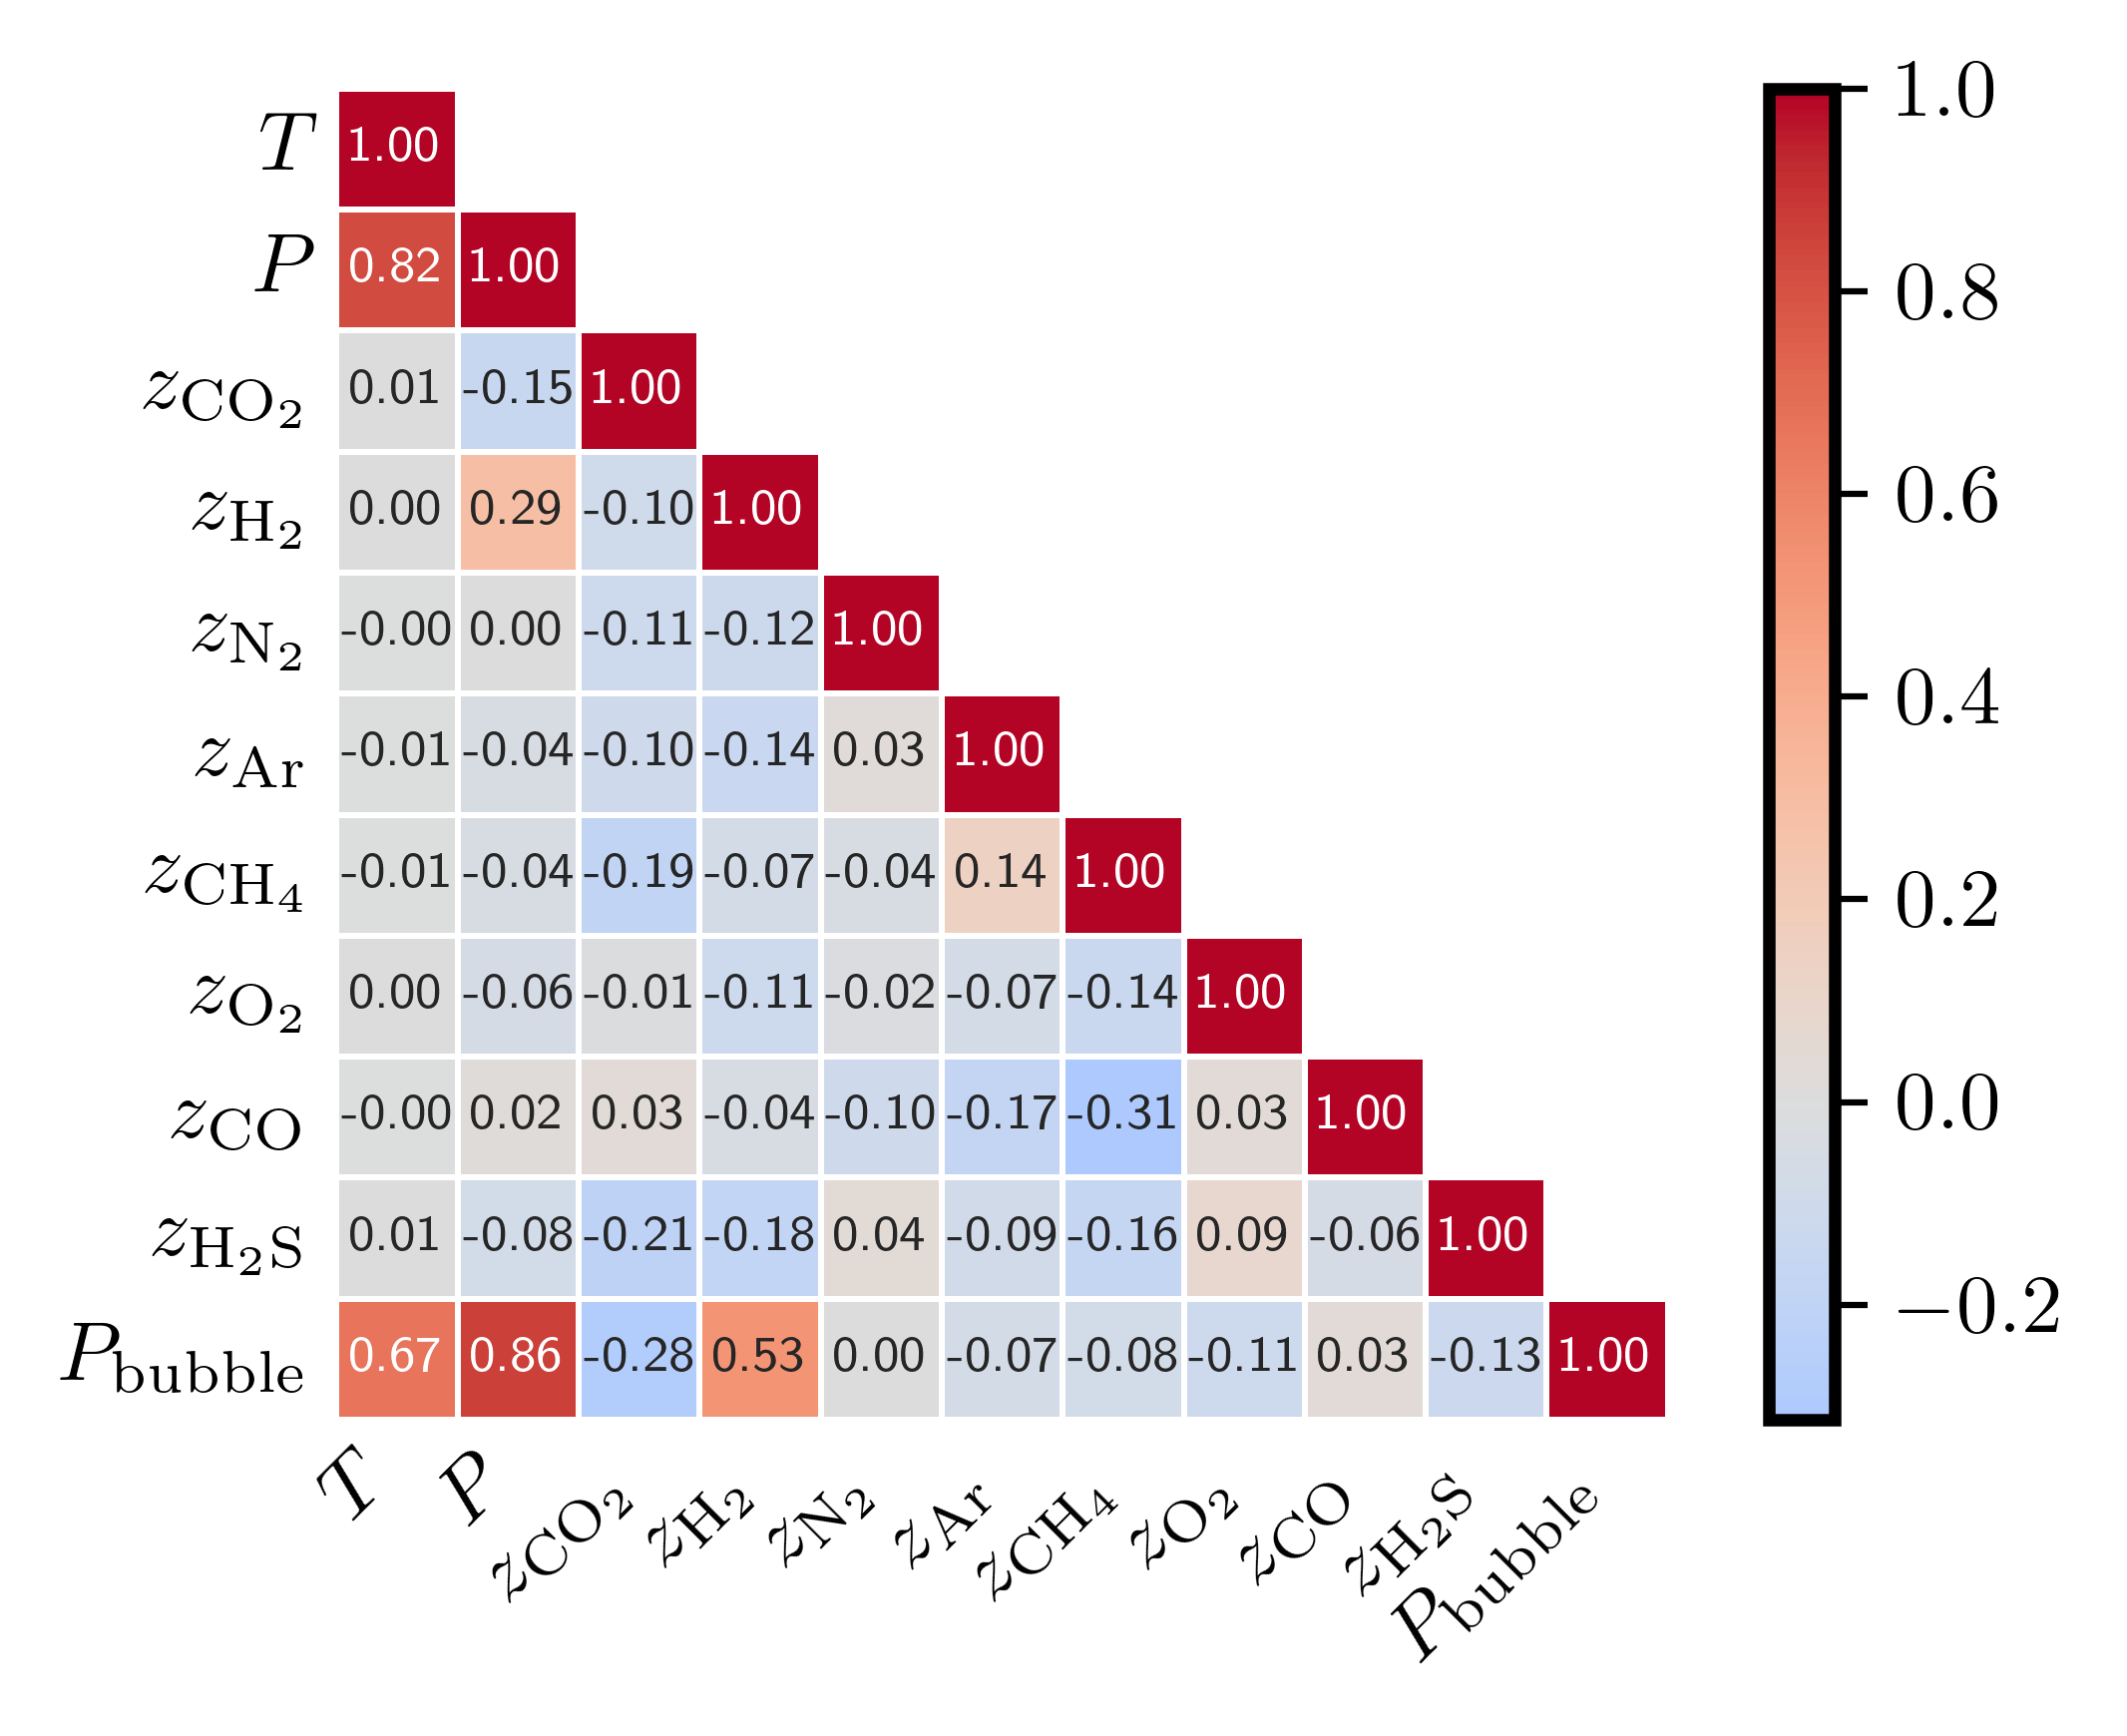

In [4]:
# Label maps for nice plotting
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "P_bubble": r"$P_{\mathrm{bubble}}$",
}

# Correlation with target
corr_with_target = df[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print("Feature correlations with P_bubble:")
print(corr_with_target)

# Correlation heatmap
numeric_cols = [col for col in features + [target] if df[col].nunique() > 1]
corr_matrix = df[numeric_cols].corr(method="spearman")
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = ps.plot_init()

cm = sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap=ps.map,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 6},
    cbar_kws={"shrink": 1}
)

cbar = cm.collections[0].colorbar
ps.style_colorbar(cbar)
ps.apply_axis_style(ax)
ax.tick_params(axis="both", length=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_correlation")
plt.show()

In [5]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("=" * 60)
print("Random Forest Model Performance for P_bubble")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  R²:   {train_r2:.6f}")
print(f"  RMSE: {train_rmse:.6f} bar")
print(f"  MAE:  {train_mae:.6f} bar")
print(f"\nTest Set:")
print(f"  R²:   {test_r2:.6f}")
print(f"  RMSE: {test_rmse:.6f} bar")
print(f"  MAE:  {test_mae:.6f} bar")

Random Forest Model Performance for P_bubble

Training Set:
  R²:   0.999714
  RMSE: 0.346375 bar
  MAE:  0.211581 bar

Test Set:
  R²:   0.997936
  RMSE: 0.926333 bar
  MAE:  0.563155 bar


In [6]:
# 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R² Scores: [0.94270943 0.96804154 0.9446395  0.97745324 0.97513043]
Mean CV R²: 0.9616 (+/- 0.0299)


Feature Importances:
pressure              0.705034
z_hydrogen            0.247143
temperature           0.018674
z_nitrogen            0.008908
z_carbon monoxide     0.007152
z_carbon dioxide      0.006462
z_argon               0.002221
z_methane             0.001542
z_hydrogen sulfide    0.001522
z_oxygen              0.001344
dtype: float64


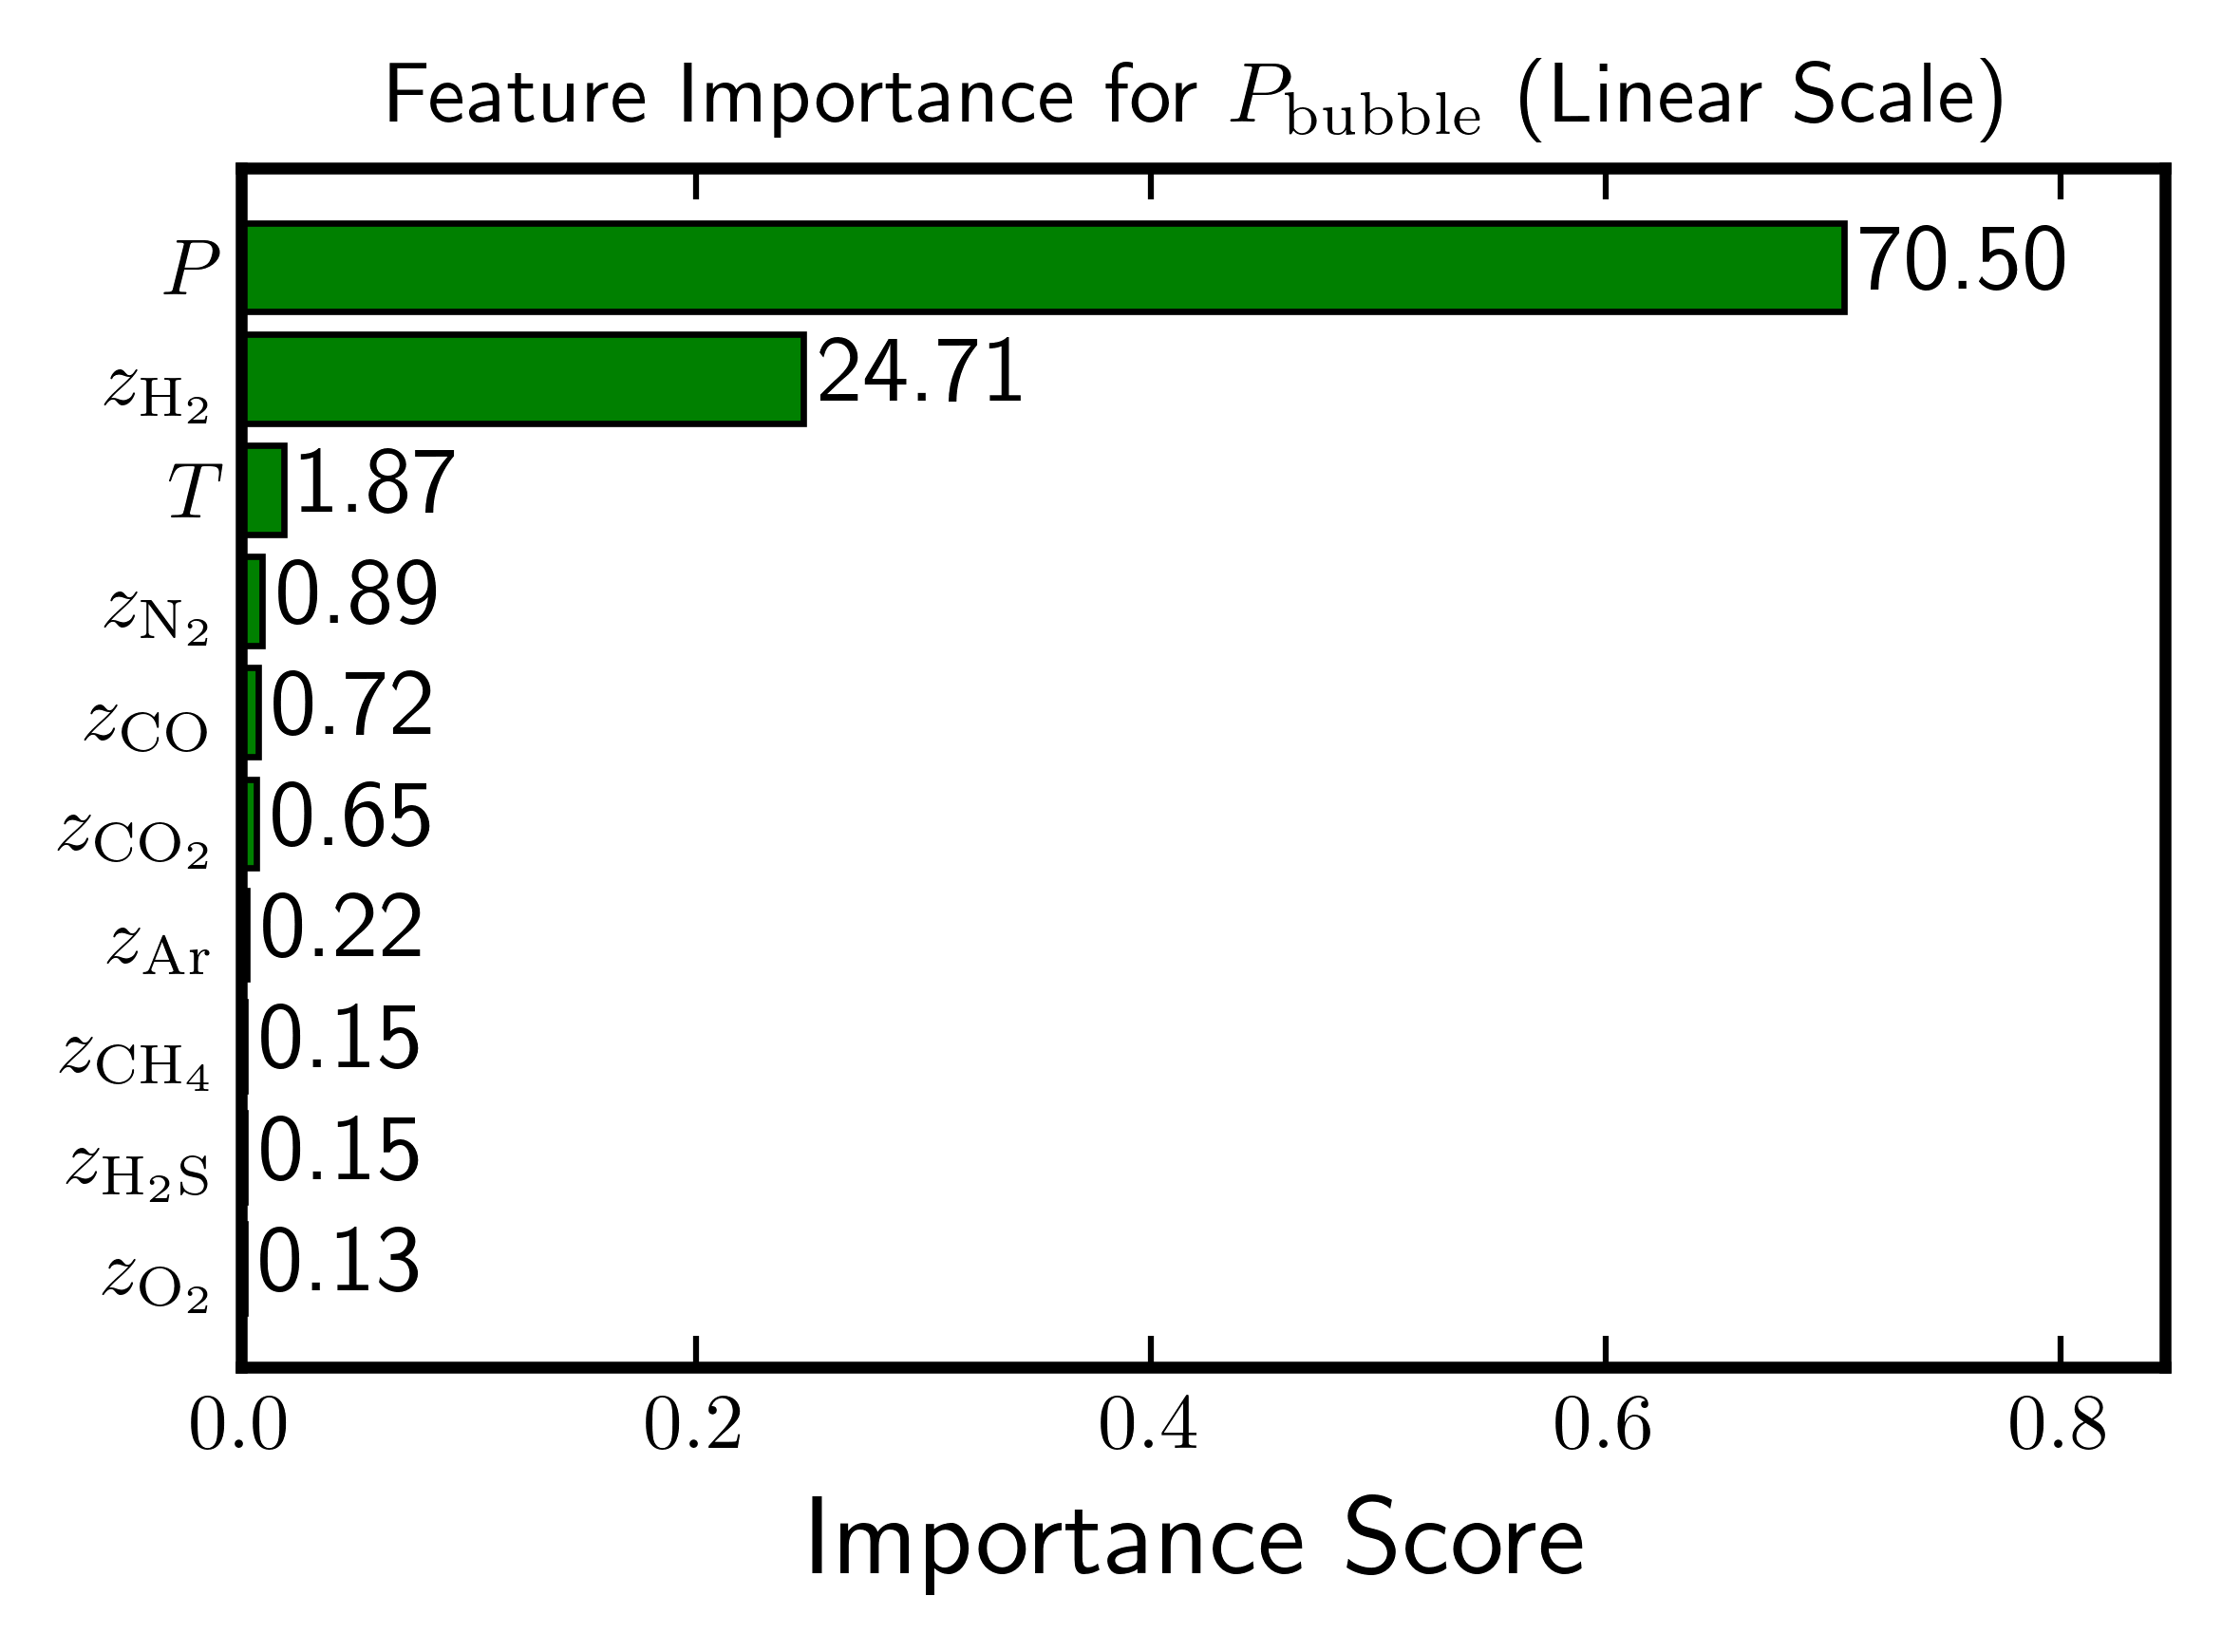

In [7]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=features)
print("Feature Importances:")
print(importance.sort_values(ascending=False))

importance_sorted = importance.sort_values()
feat_names = [label_map.get(col, col) for col in importance_sorted.index]
imp_vals = importance_sorted.values
imp_percent = (imp_vals / imp_vals.sum()) * 100

# Plot feature importance (Linear Scale)
fig, ax = ps.plot_init()

bars = ax.barh(
    feat_names,
    imp_vals,
    color="green",
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Importance Score", fontsize=ps.label_fontsize)
ax.set_title(r"Feature Importance for $P_{\mathrm{bubble}}$ (Linear Scale)", fontsize=ps.title_fontsize * 0.9, fontweight="bold")

for bar, val, pct in zip(bars, imp_vals, imp_percent):
    ax.text(
        val + 0.01 * imp_vals.max(),
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center",
        ha="left",
        fontsize=ps.label_fontsize * 0.85
    )

ax.set_xlim(0, imp_vals.max() * 1.2)
ps.apply_axis_style(ax)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_feature_importance_linear")
plt.show()

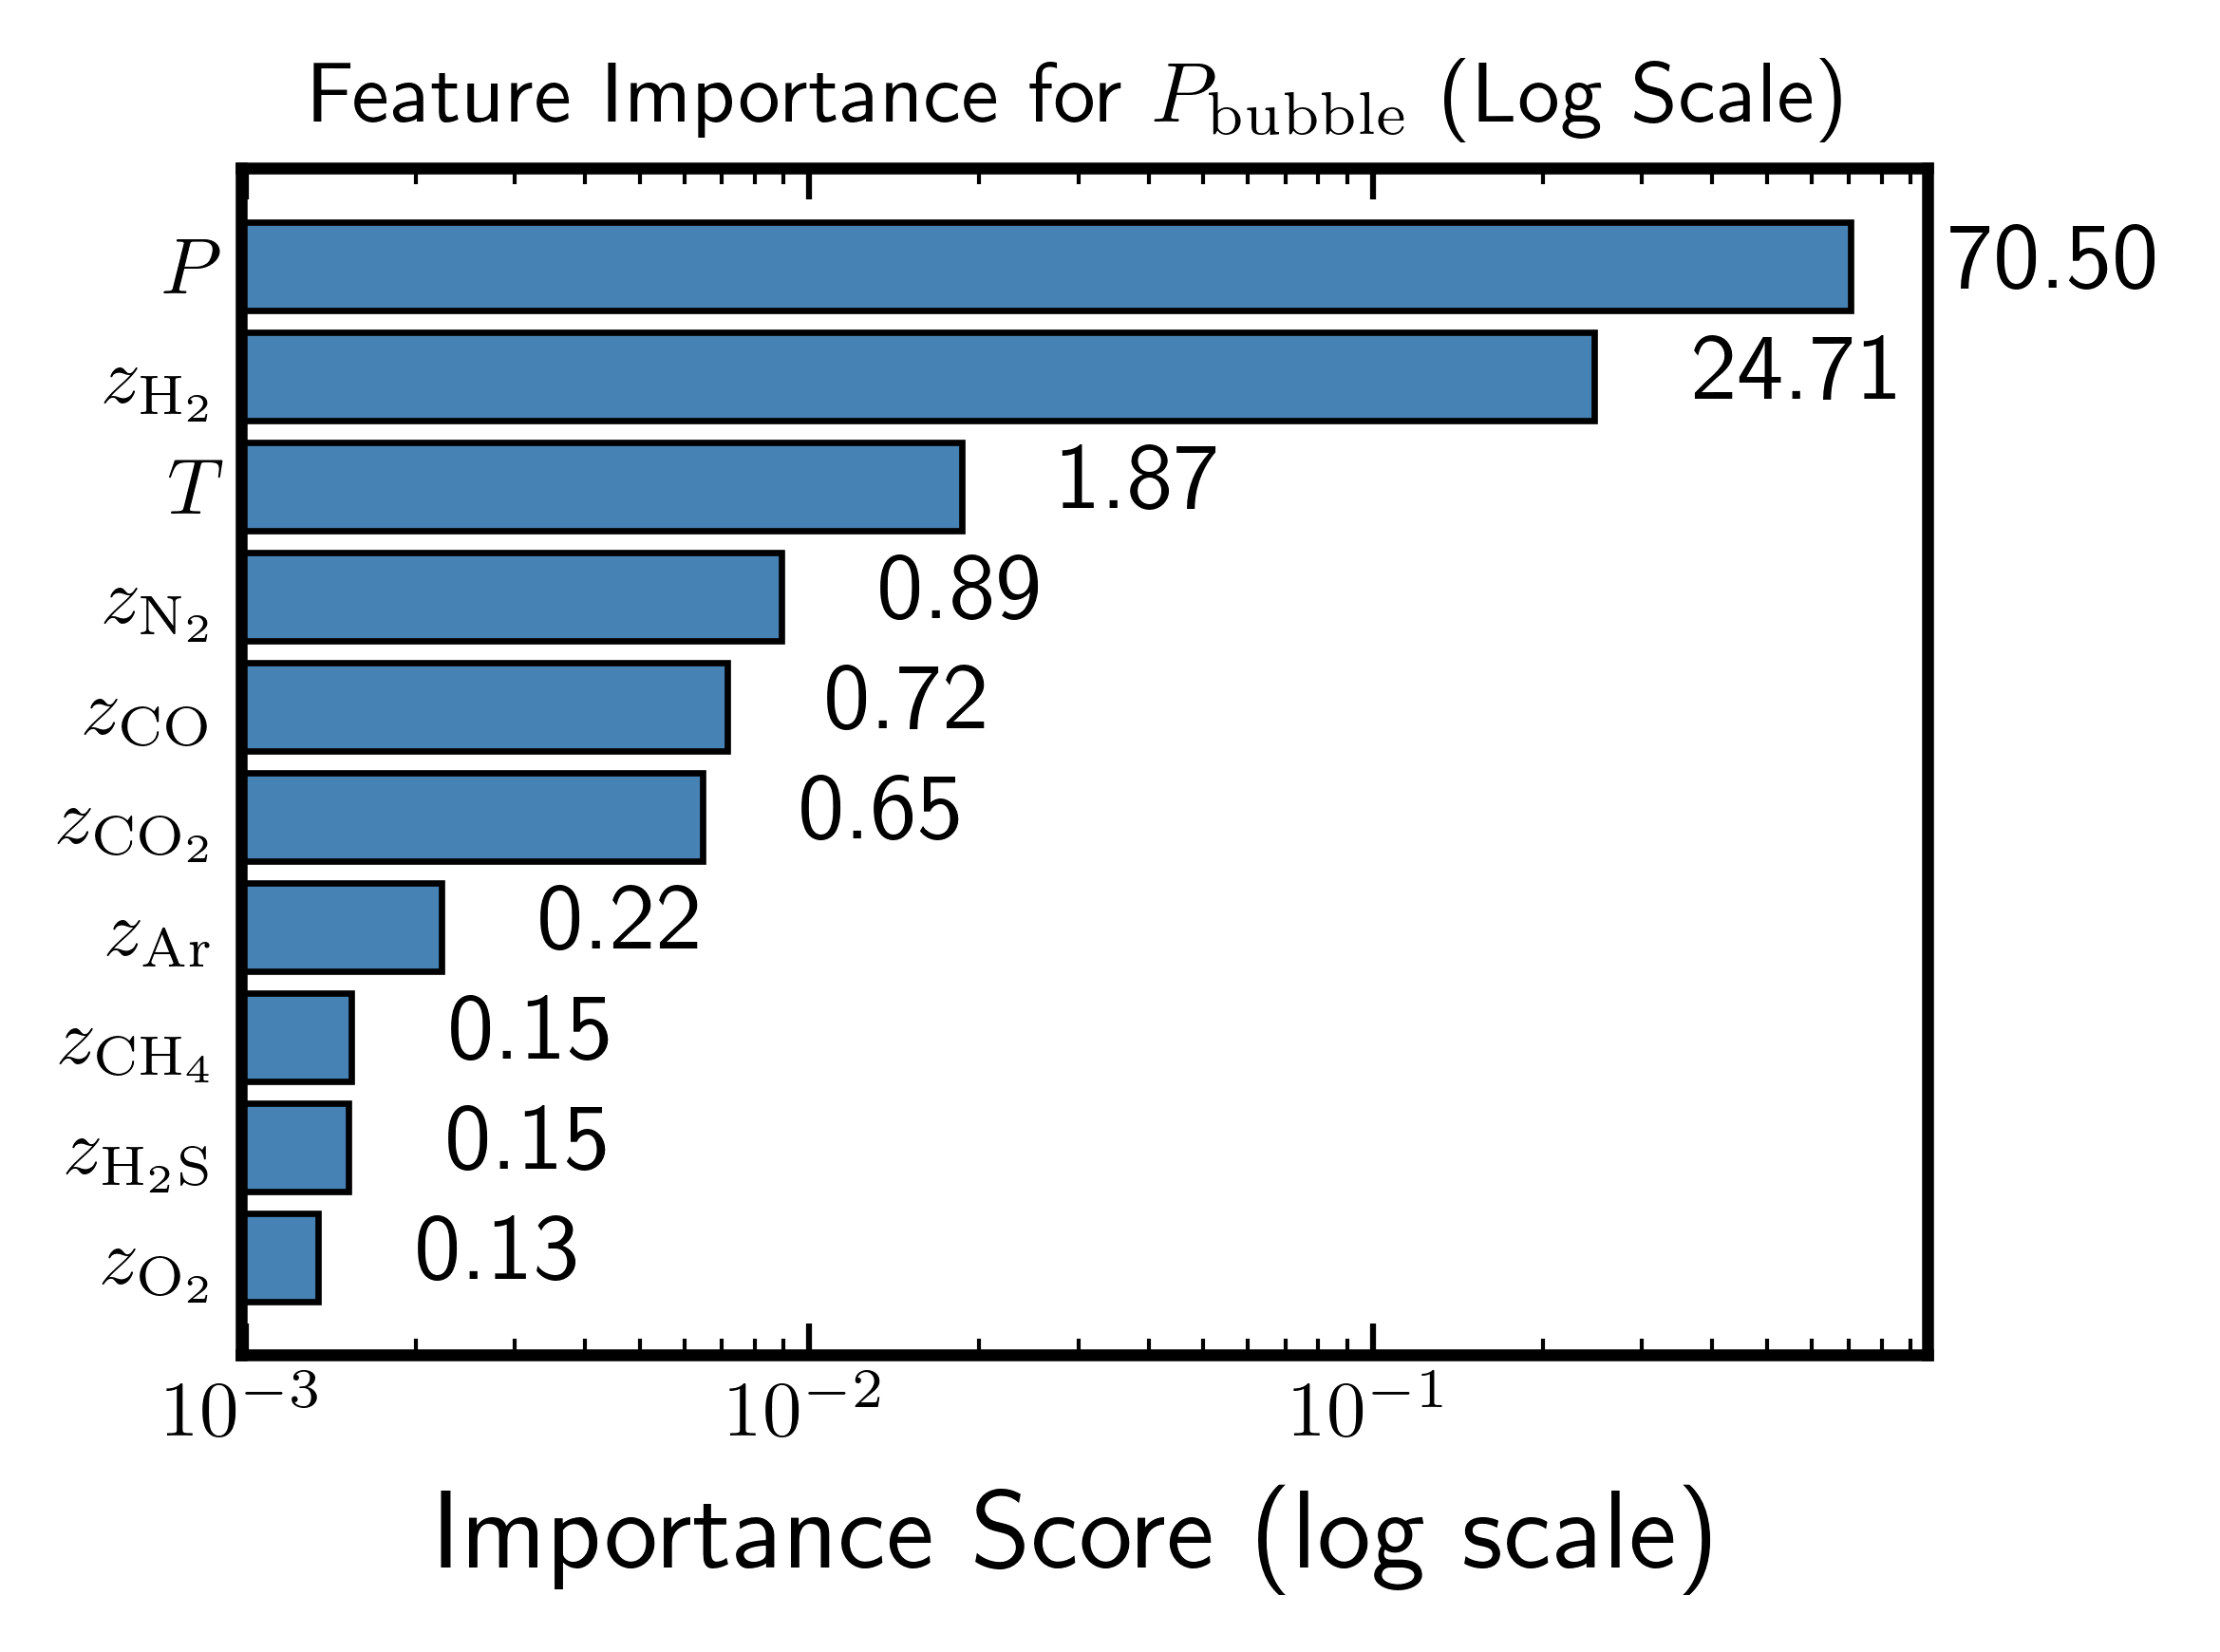

In [8]:
# Plot feature importance (Log Scale)
fig, ax = ps.plot_init()

bars = ax.barh(
    feat_names,
    imp_vals,
    color="steelblue",
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Importance Score (log scale)", fontsize=ps.label_fontsize)
ax.set_title(r"Feature Importance for $P_{\mathrm{bubble}}$ (Log Scale)", fontsize=ps.title_fontsize * 0.9, fontweight="bold")
ax.set_xscale("log")

for bar, val, pct in zip(bars, imp_vals, imp_percent):
    ax.text(
        val * 1.5,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center",
        ha="left",
        fontsize=ps.label_fontsize * 0.85
    )

ps.apply_axis_style(ax)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_feature_importance_log")
plt.show()

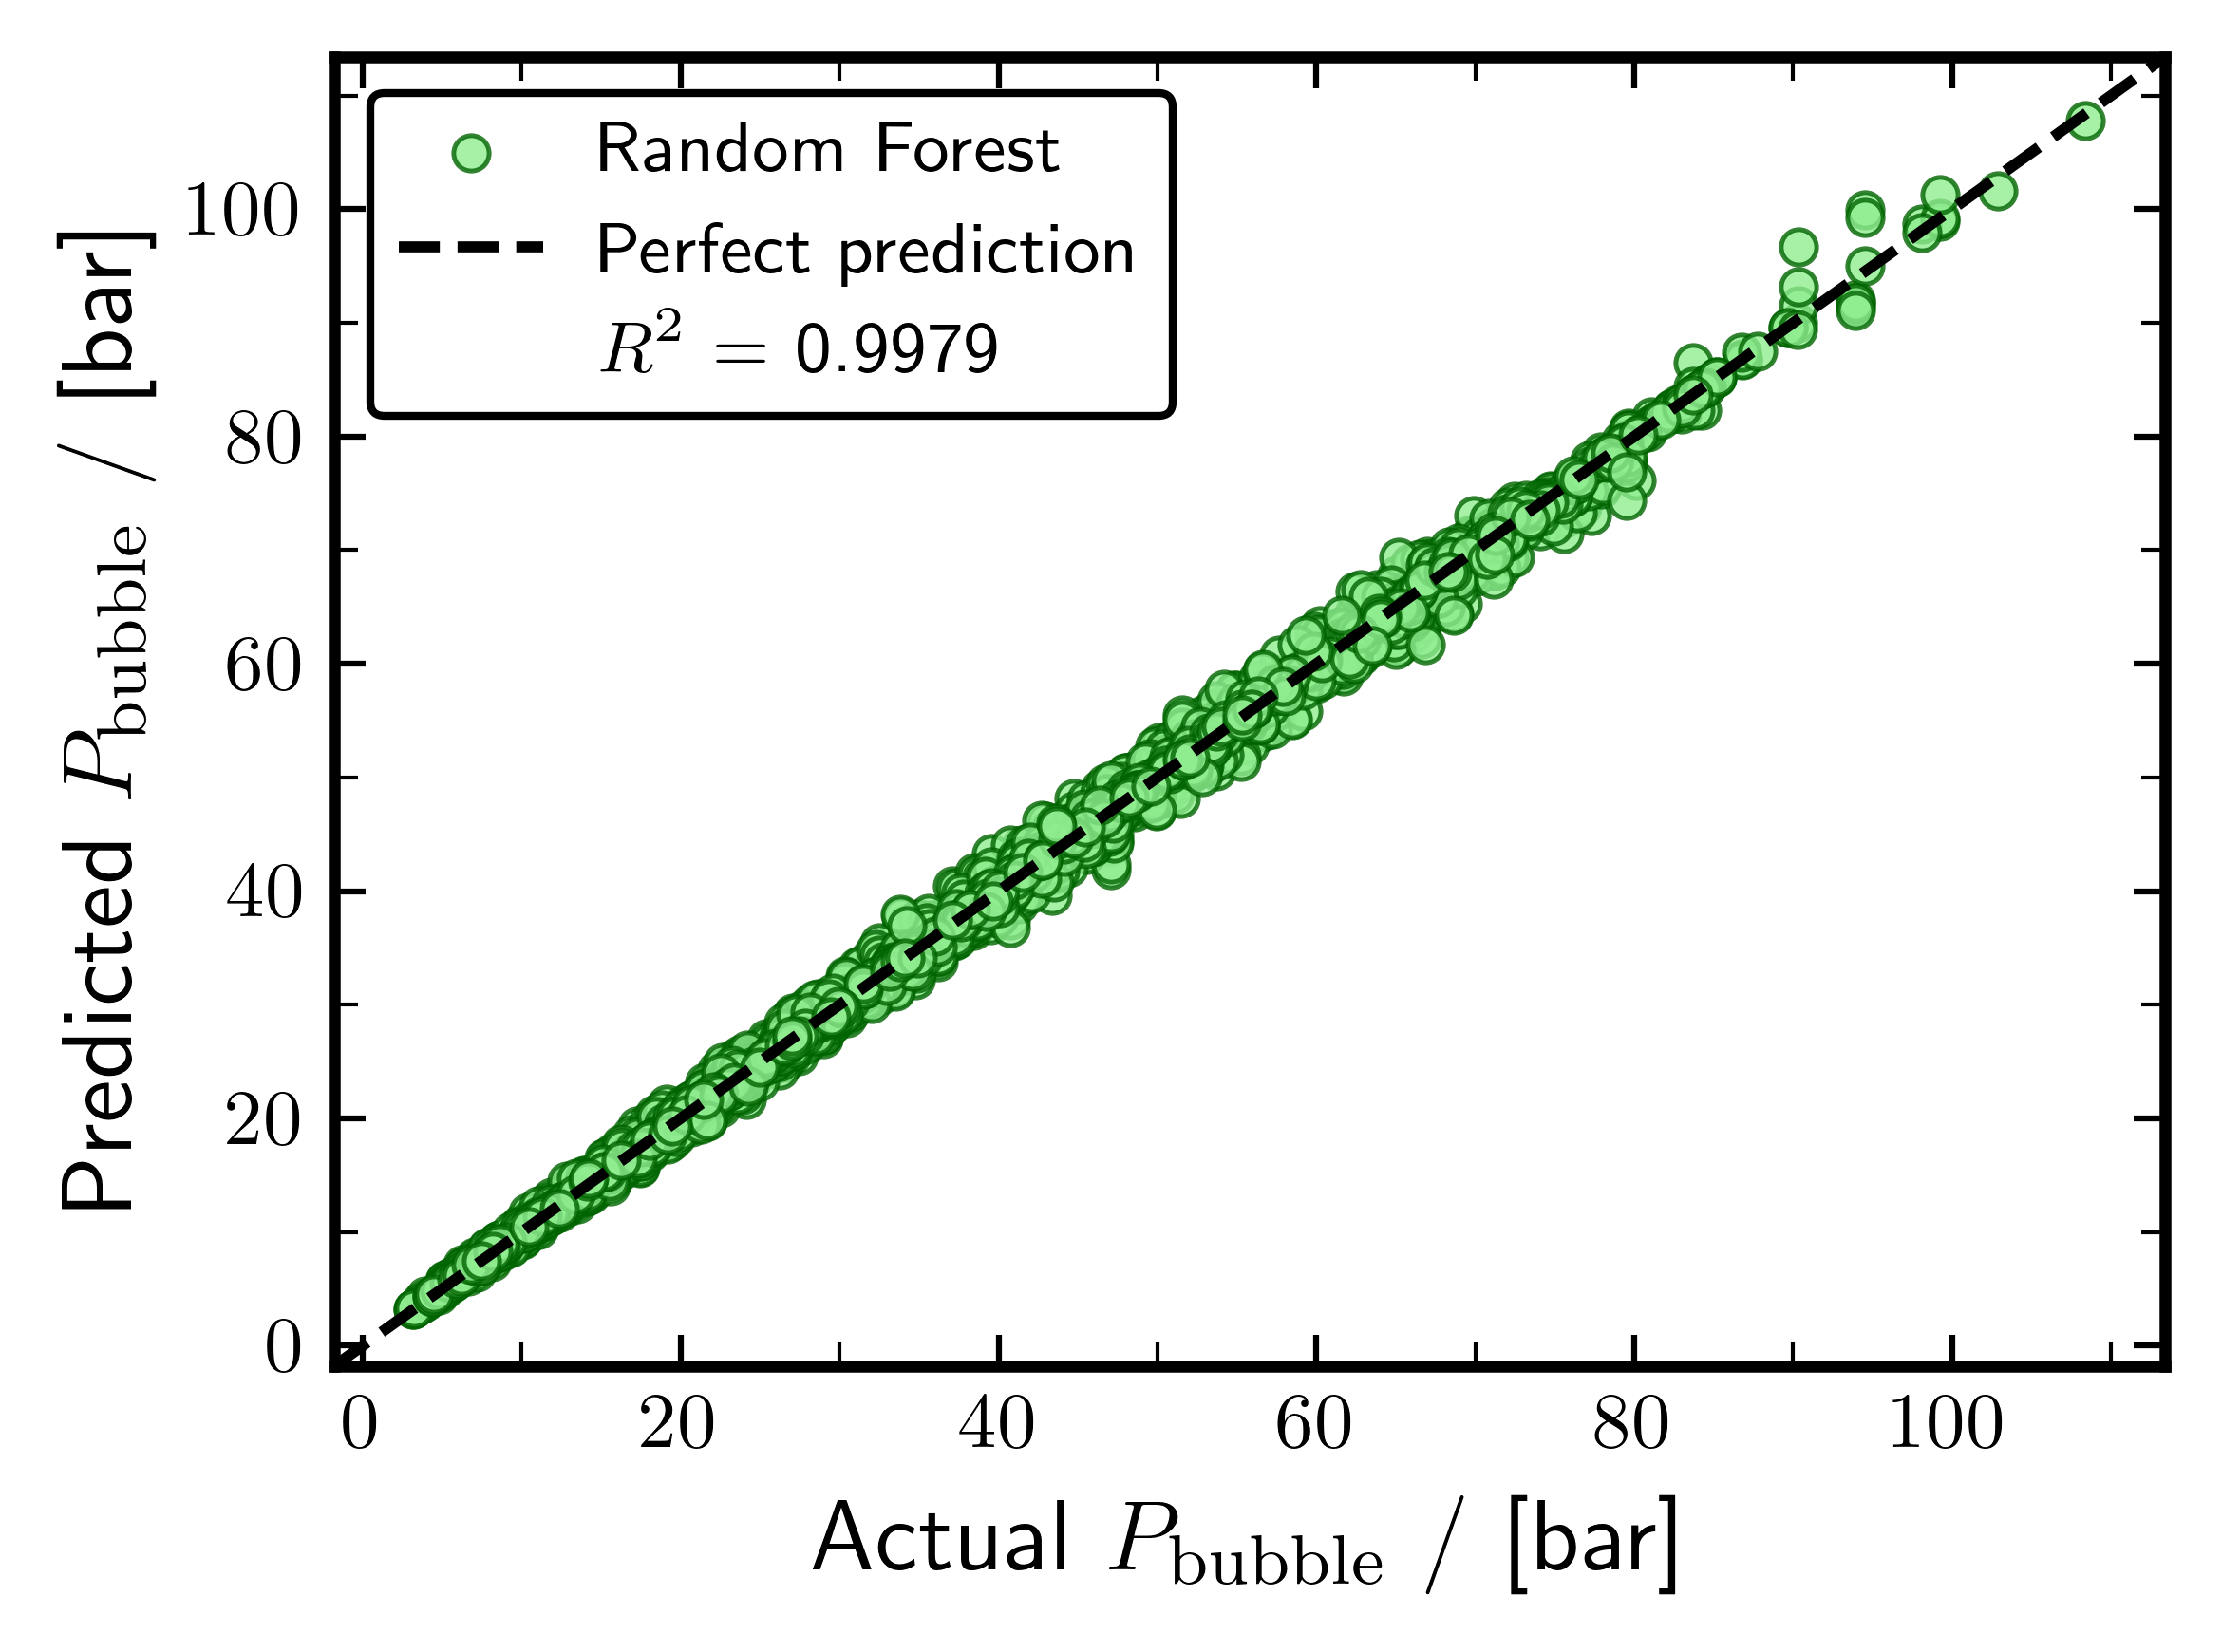

In [9]:
# Parity plot
fig, ax = ps.plot_init()

lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]
lims = [lims[0] - 5, lims[1] + 5]

ax.scatter(
    y_test, y_test_pred,
    alpha=0.8, s=20,
    facecolors="lightgreen",
    edgecolors="darkgreen",
    linewidths=0.6,
    label="Random Forest"
)

ax.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"Actual $P_{\mathrm{bubble}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $P_{\mathrm{bubble}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
dummy_r2 = Line2D([], [], linestyle="none", label=rf"$R^2$ = {test_r2:.4f}")

handles, labels = ax.get_legend_handles_labels()
handles.append(dummy_r2)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.65,
    loc="upper left",
    edgecolor="black",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_parity_plot")
plt.show()

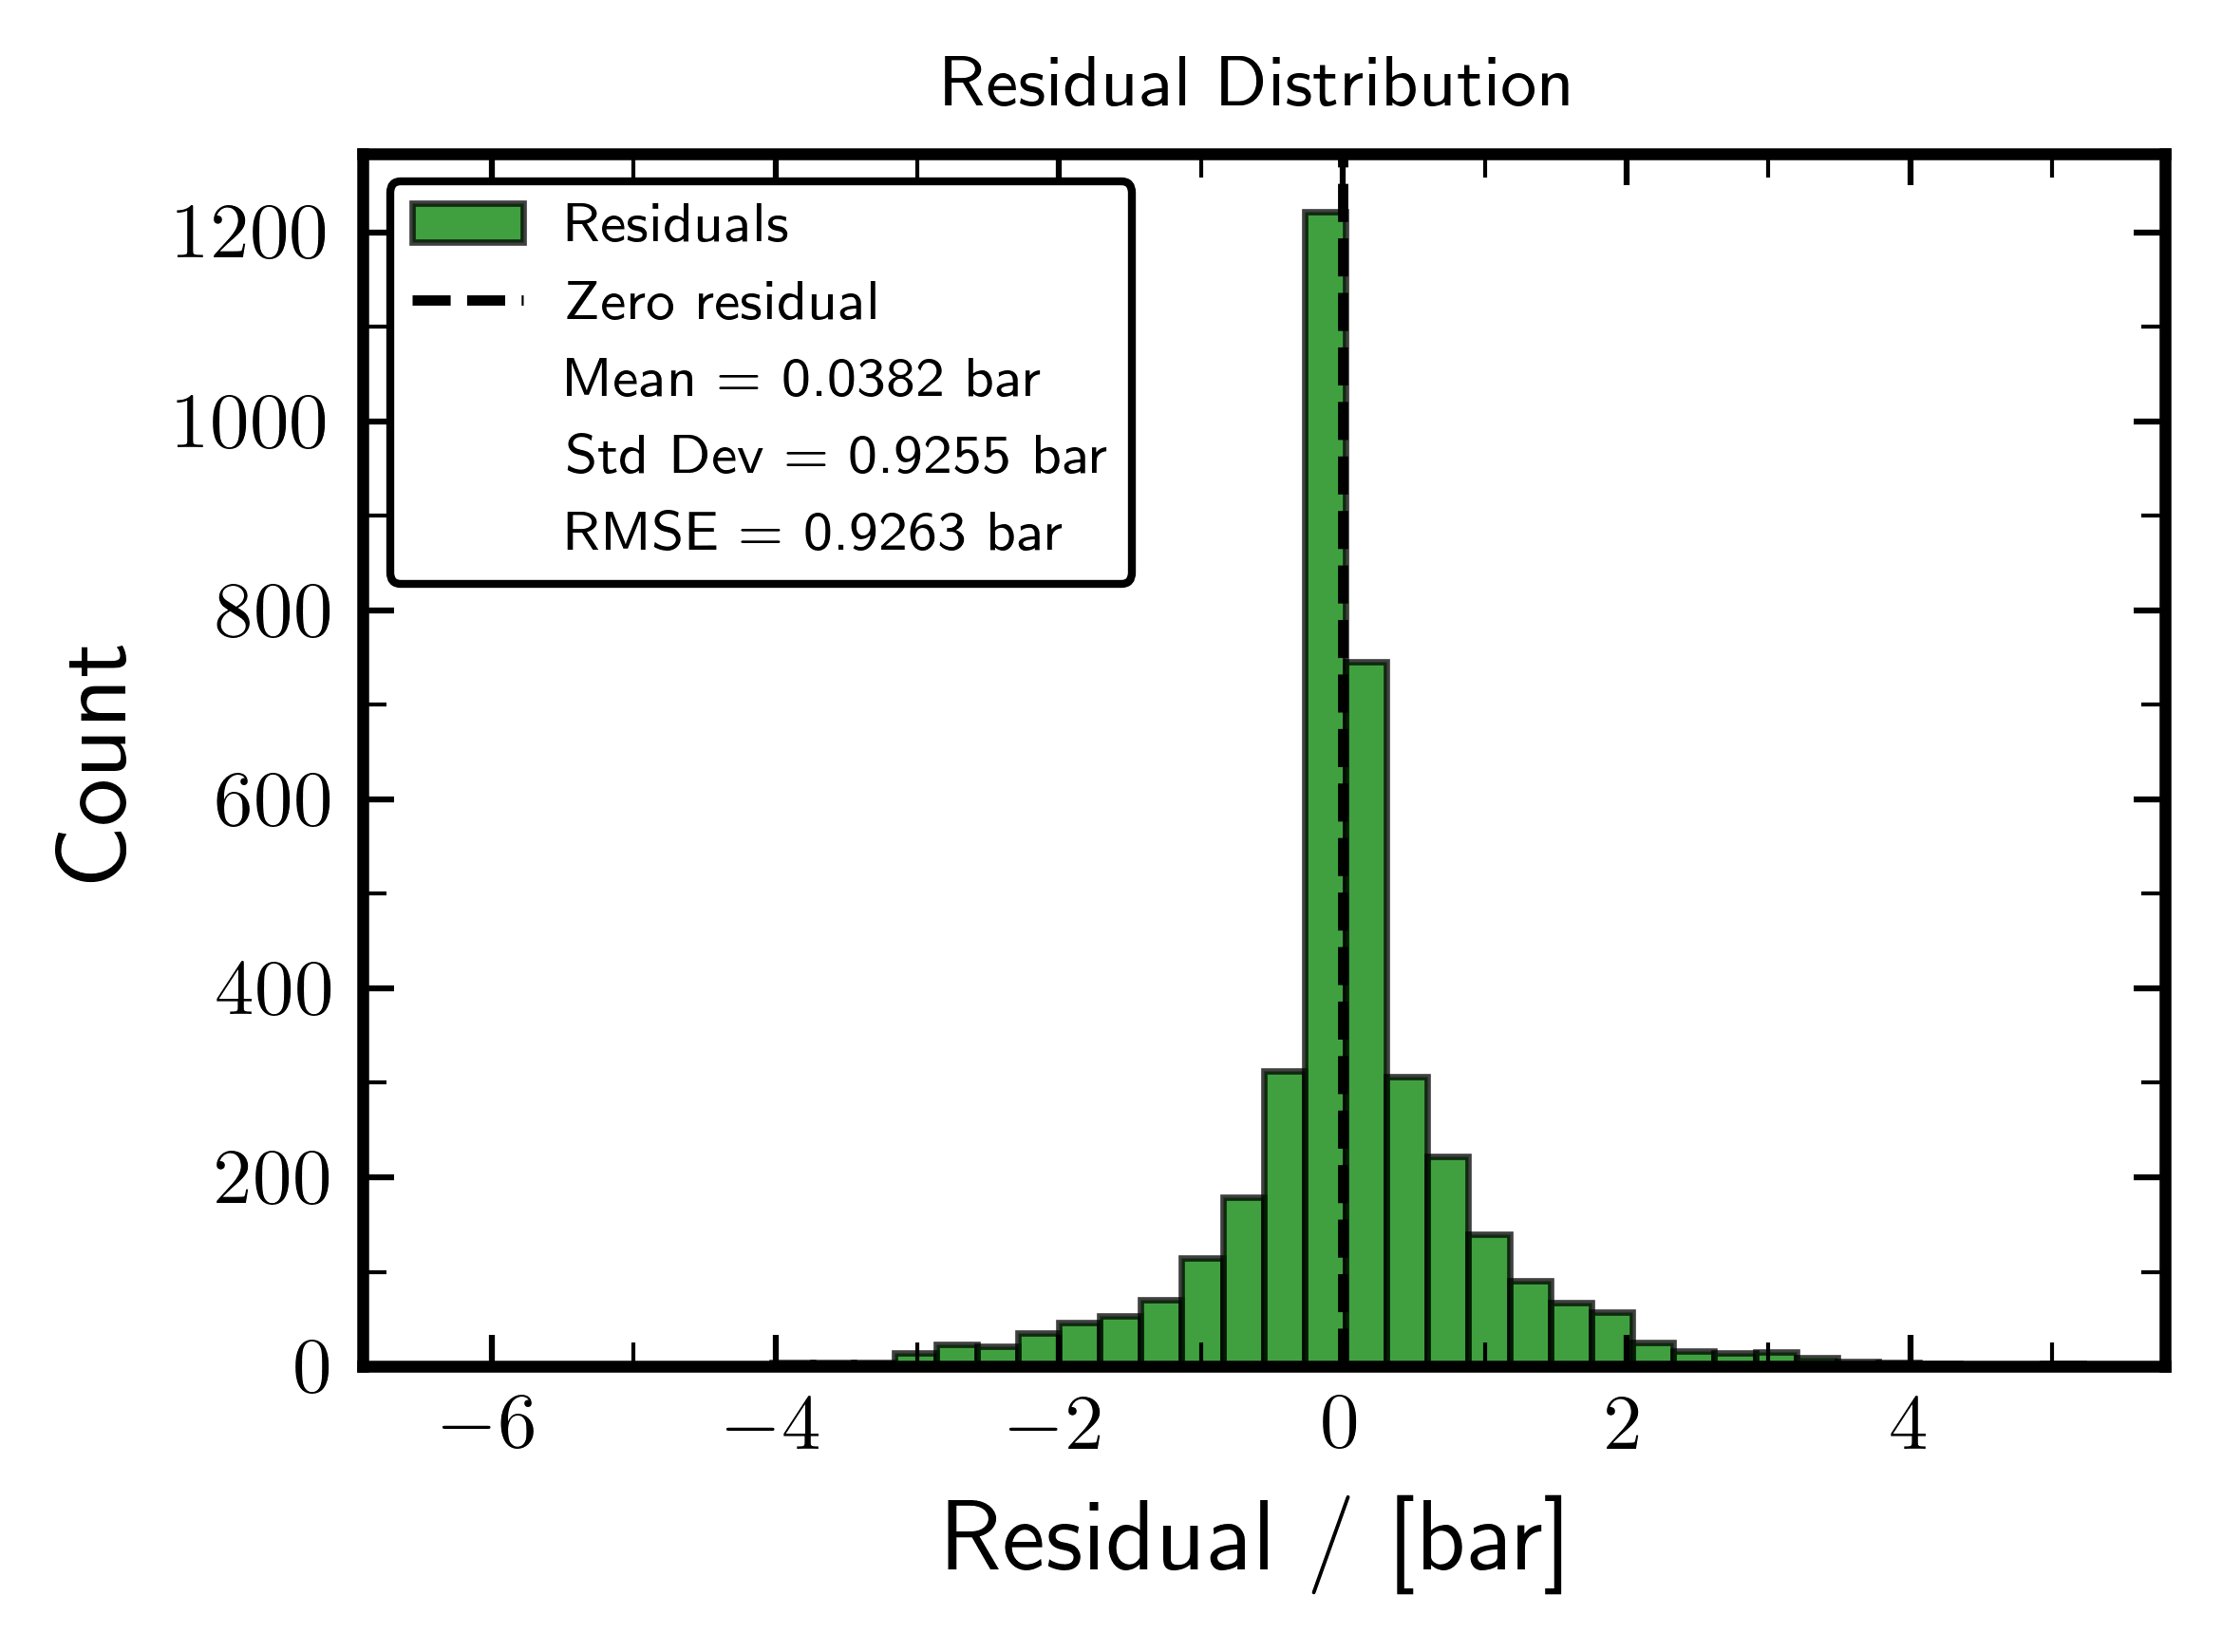

In [10]:
# Residual distribution
residuals = y_test.values - y_test_pred

fig, ax = ps.plot_init()

ax.hist(
    residuals,
    bins=40,
    alpha=0.75,
    color="green",
    edgecolor="black",
    linewidth=0.8,
    label="Residuals"
)

ax.axvline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

mean_resid = residuals.mean()
std_resid = residuals.std()

ax.set_xlabel(r"Residual / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Count", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"Residual Distribution", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

dummy_mean = Line2D([], [], linestyle="none", label=rf"Mean = {mean_resid:.4f} bar")
dummy_std  = Line2D([], [], linestyle="none", label=rf"Std Dev = {std_resid:.4f} bar")
dummy_rmse = Line2D([], [], linestyle="none", label=rf"RMSE = {test_rmse:.4f} bar")

handles, labels = ax.get_legend_handles_labels()
handles.extend([dummy_mean, dummy_std, dummy_rmse])

ps.apply_axis_style(ax)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.5,
    loc="upper left",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_residual_distribution")
plt.show()

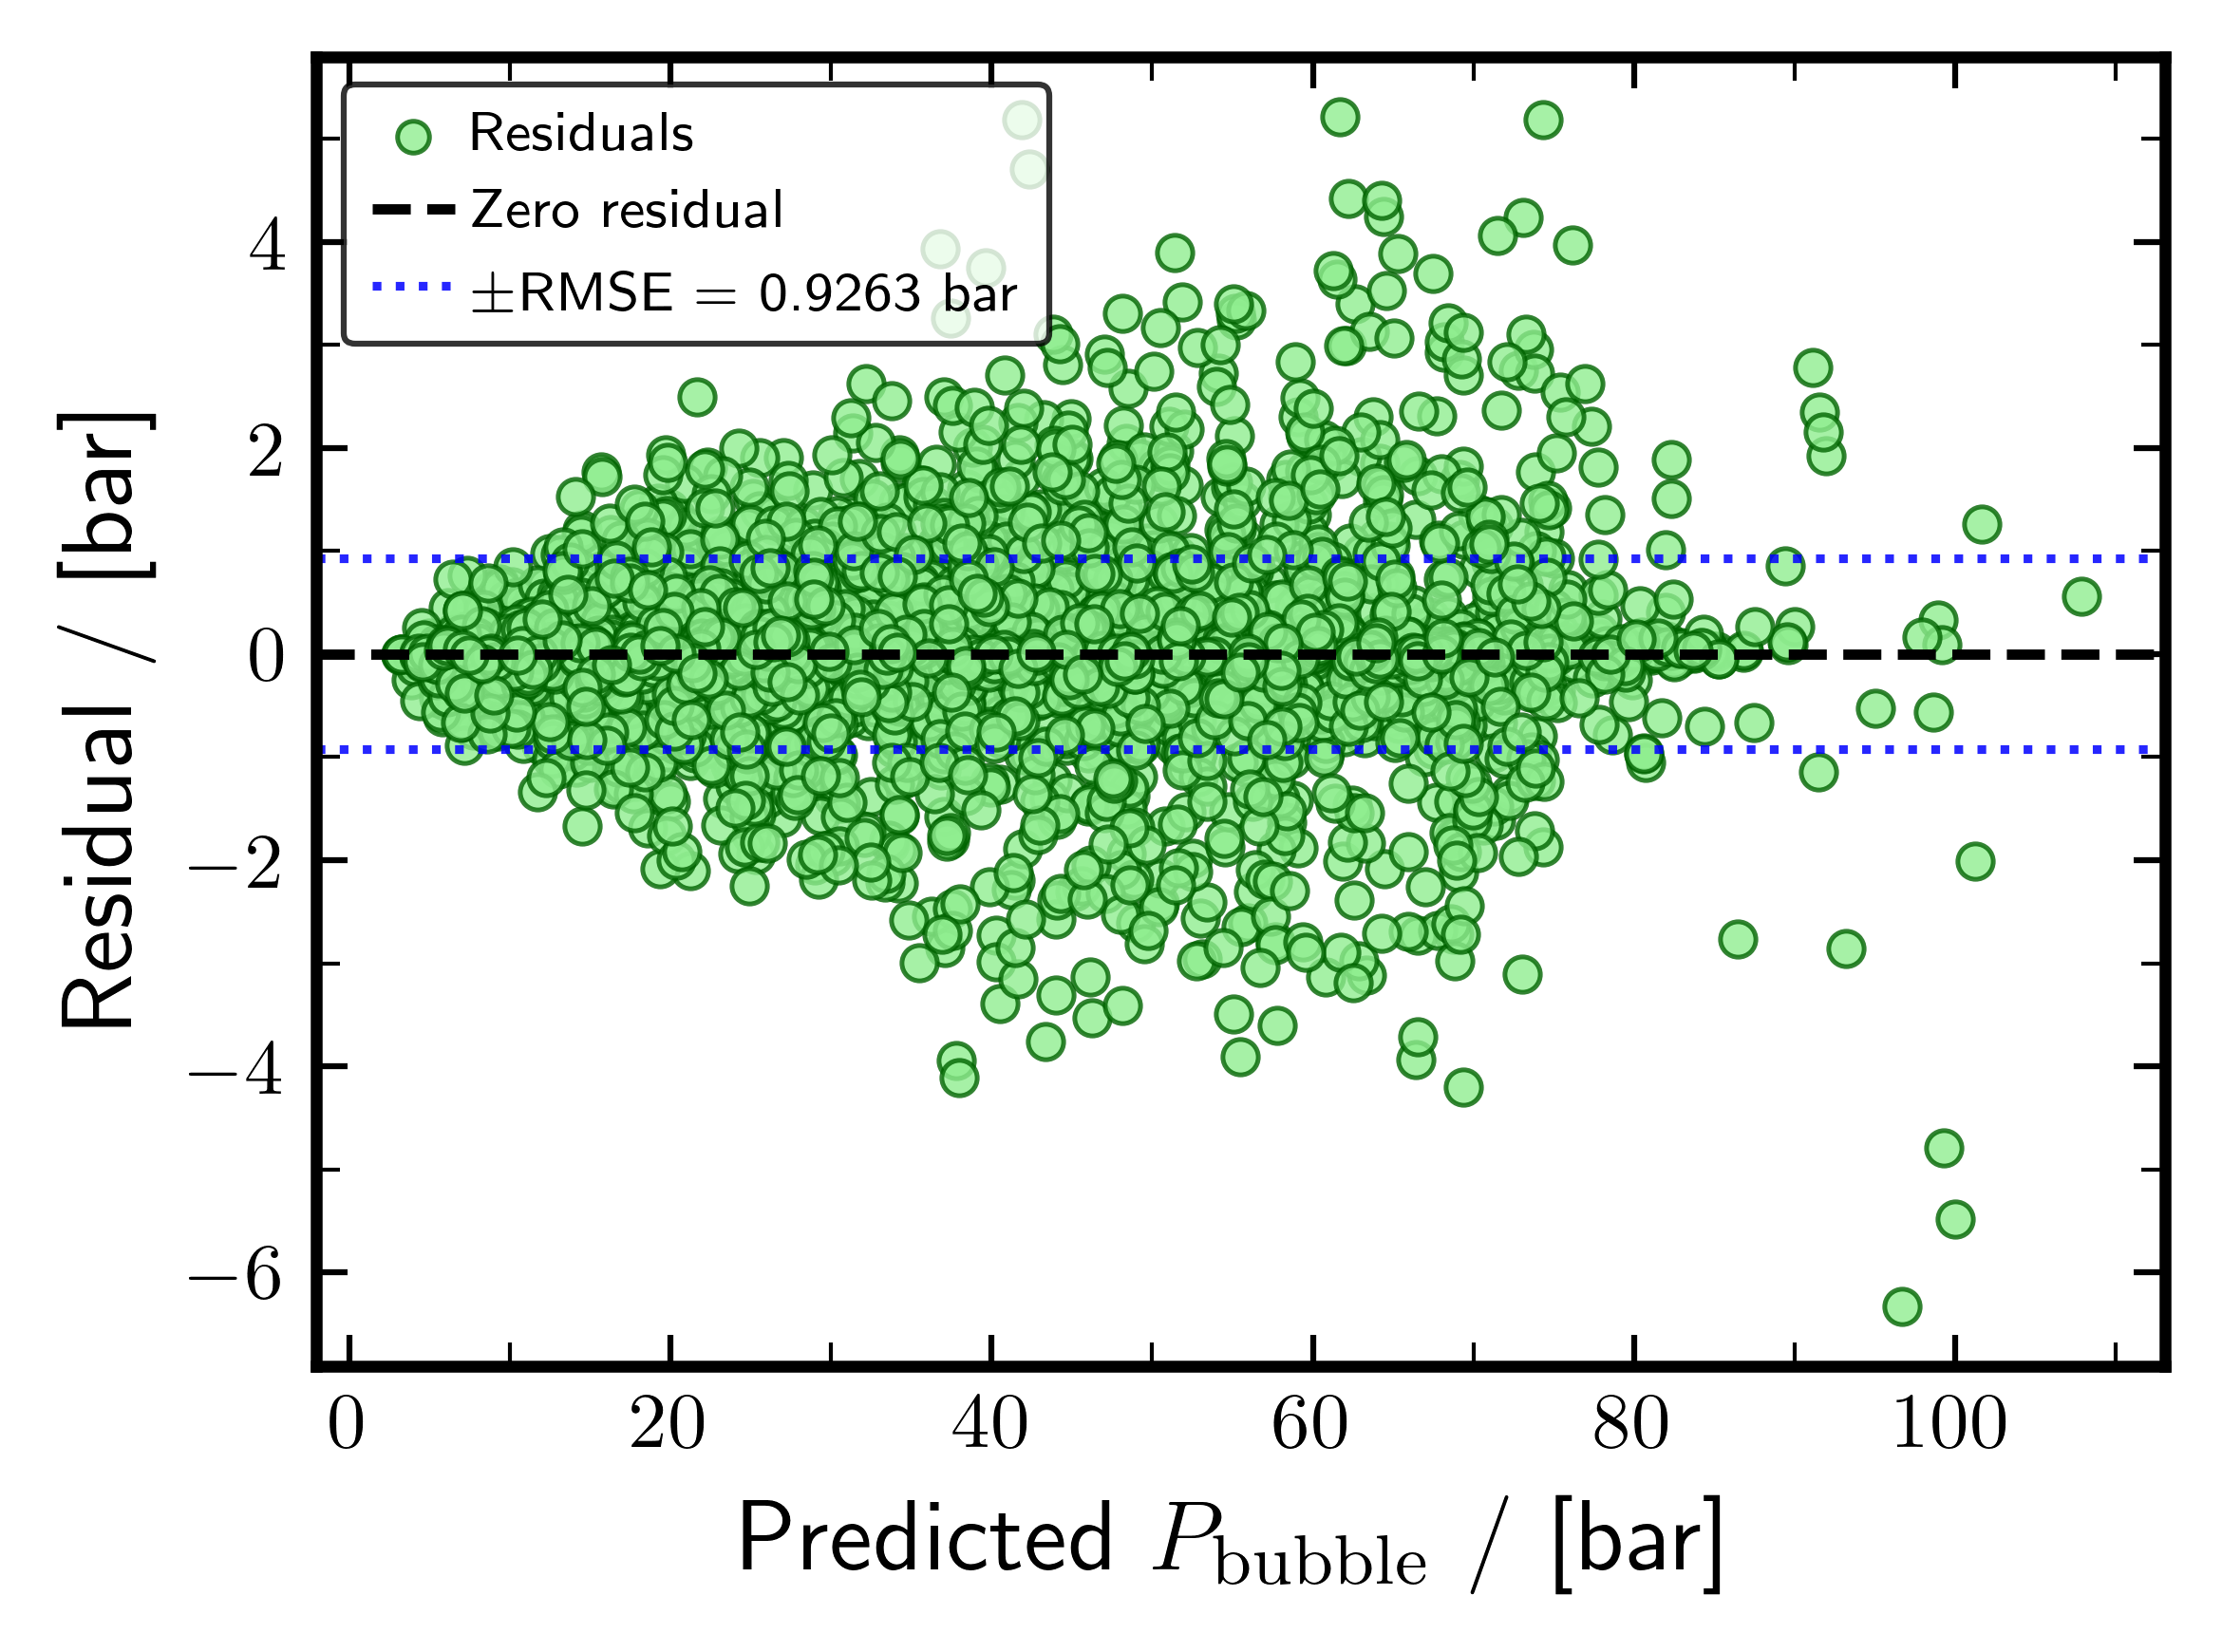

In [11]:
# Residuals vs Predicted
fig, ax = ps.plot_init()

ax.scatter(y_test_pred, residuals, alpha=0.8, s=20, facecolors="lightgreen", edgecolors="darkgreen", linewidths=0.6, label="Residuals")

ax.axhline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")
ax.axhline(test_rmse, color="blue", linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {test_rmse:.4f} bar")
ax.axhline(-test_rmse, color="blue", linewidth=1.1, linestyle=":", alpha=0.85)

ax.set_xlabel(r"Predicted $P_{\mathrm{bubble}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Residual / [bar]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=ps.label_fontsize * 0.5, loc="upper left")

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "RF_P_bubble_residual_vs_predicted")
plt.show()

In [12]:
print("=" * 70)
print("SUMMARY: Random Forest Model for P_bubble Prediction")
print("=" * 70)
print(f"\nModel Configuration:")
print(f"  - n_estimators: {rf_model.n_estimators}")
print(f"  - max_depth: {rf_model.max_depth}")
print(f"  - Features used: {features}")
print(f"\nPerformance Metrics (Test Set):")
print(f"  - R²:   {test_r2:.6f}")
print(f"  - RMSE: {test_rmse:.6f} bar")
print(f"  - MAE:  {test_mae:.6f} bar")
print(f"\nCross-Validation:")
print(f"  - Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"\nFeature Importances:")
for fname, val, pct in sorted(zip(feat_names, imp_vals, imp_percent), key=lambda x: x[2], reverse=True):
    bar_length = int(pct / 2)
    bar = "█" * bar_length
    print(f"  {fname:20s} | {pct:6.2f}% | {bar}")

SUMMARY: Random Forest Model for P_bubble Prediction

Model Configuration:
  - n_estimators: 500
  - max_depth: None
  - Features used: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Performance Metrics (Test Set):
  - R²:   0.997936
  - RMSE: 0.926333 bar
  - MAE:  0.563155 bar

Cross-Validation:
  - Mean CV R²: 0.9616 (+/- 0.0299)

Feature Importances:
  $P$                  |  70.50% | ███████████████████████████████████
  $z_{\mathrm{H_2}}$   |  24.71% | ████████████
  $T$                  |   1.87% | 
  $z_{\mathrm{N_2}}$   |   0.89% | 
  $z_{\mathrm{CO}}$    |   0.72% | 
  $z_{\mathrm{CO_2}}$  |   0.65% | 
  $z_{\mathrm{Ar}}$    |   0.22% | 
  $z_{\mathrm{CH_4}}$  |   0.15% | 
  $z_{\mathrm{H_2S}}$  |   0.15% | 
  $z_{\mathrm{O_2}}$   |   0.13% | 
